# Self-Pruning Neural Network

## Problem Description
In the real world, deploying large neural networks is often constrained by memory and computational budgets. A common technique to make models smaller and faster is "pruning," where you remove less important weights or neurons after training. This challenge takes that idea a step further. The task is to design and implement a neural network that learns to prune itself during the training process. Instead of a post-training step, the network will have a built-in mechanism to identify and dynamically remove its own weakest connections, adapting its architecture on the fly.

In [ ]:
import os
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from typing import Tuple, List, Dict, Any

# --- 1. Reproducibility ---
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# --- 2. Data Loaders ---
def get_dataloaders(batch_size: int = 256, num_workers: int = 0) -> Tuple[DataLoader, DataLoader]:
    mean = (0.4914, 0.4822, 0.4465)
    std = (0.2023, 0.1994, 0.2010)
    
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    
    return train_loader, test_loader

# --- 3. Prunable Linear Layer ---
class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, init_gate_score: float = 2.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.init_gate_score = init_gate_score

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter("bias", None)

        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)
        nn.init.constant_(self.gate_scores, self.init_gate_score)

    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = self.get_gates()
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_sparsity_loss(self) -> torch.Tensor:
        return self.get_gates().sum()

    def get_sparsity_details(self, threshold: float = 0.01) -> Tuple[int, int]:
        gates = self.get_gates()
        return (gates < threshold).sum().item(), gates.numel()

# --- 4. Self-Pruning MLP Architecture ---
class SelfPruningMLP(nn.Module):
    def __init__(self, in_features: int = 3072, hidden_dims: List[int] = None, out_features: int = 10, init_gate_score: float = 2.0):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256, 128]
            
        self.in_features = in_features
        self.hidden_dims = hidden_dims
        self.out_features = out_features
        
        layers = []
        prev_dim = in_features
        for dim in hidden_dims:
            layers.append(PrunableLinear(prev_dim, dim, init_gate_score=init_gate_score))
            layers.append(nn.ReLU())
            prev_dim = dim
            
        layers.append(PrunableLinear(prev_dim, out_features, init_gate_score=init_gate_score))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.network(x)

    def get_prunable_layers(self) -> List[PrunableLinear]:
        return [module for module in self.modules() if isinstance(module, PrunableLinear)]

    def get_sparsity_loss(self) -> torch.Tensor:
        sparsity_loss = torch.tensor(0.0, device=self.device)
        for module in self.get_prunable_layers():
            sparsity_loss = sparsity_loss + module.get_sparsity_loss()
        return sparsity_loss

    def get_sparsity_details(self, threshold: float = 0.01) -> Tuple[int, int, float]:
        total_pruned, total_weights = 0, 0
        for module in self.get_prunable_layers():
            pruned, total = module.get_sparsity_details(threshold)
            total_pruned += pruned
            total_weights += total
        sparsity_percentage = (total_pruned / total_weights) * 100.0 if total_weights > 0 else 0.0
        return total_pruned, total_weights, sparsity_percentage

    def get_gate_statistics(self) -> dict:
        all_gates = []
        with torch.no_grad():
            for module in self.get_prunable_layers():
                all_gates.append(module.get_gates().detach().flatten())
        gates = torch.cat(all_gates)
        return {
            "min_gate": gates.min().item(),
            "max_gate": gates.max().item(),
            "mean_gate": gates.mean().item(),
            "median_gate": gates.median().item(),
            "below_0.10_pct": ((gates < 0.10).float().mean().item() * 100),
            "below_0.05_pct": ((gates < 0.05).float().mean().item() * 100),
            "below_0.01_pct": ((gates < 0.01).float().mean().item() * 100)
        }

    def get_all_gate_values(self) -> torch.Tensor:
        all_gates = []
        with torch.no_grad():
            for module in self.get_prunable_layers():
                all_gates.append(module.get_gates().detach().cpu().flatten())
        return torch.cat(all_gates)

    @property
    def device(self) -> torch.device:
        try:
            return next(self.parameters()).device
        except StopIteration:
            return torch.device("cpu")

# --- 5. Training and Evaluation Logic ---
def get_optimizer(model: SelfPruningMLP, lr: float = 1e-3, gate_lr: float = 5e-3, weight_decay: float = 1e-4) -> optim.Optimizer:
    decay_params, no_decay_params, gate_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "gate_scores" in name:
            gate_params.append(param)
        elif "bias" in name:
            no_decay_params.append(param)
        else:
            decay_params.append(param)
            
    optimizer_groups = [
        {"params": decay_params, "lr": lr, "weight_decay": weight_decay},
        {"params": no_decay_params, "lr": lr, "weight_decay": 0.0},
        {"params": gate_params, "lr": gate_lr, "weight_decay": 0.0}
    ]
    return optim.Adam(optimizer_groups)

def train_epoch(model: SelfPruningMLP, loader: DataLoader, criterion: nn.Module, optimizer: optim.Optimizer, lambda_: float, device: torch.device) -> Tuple[float, float, float]:
    model.train()
    total_class_loss, total_sparsity_loss, total_loss = 0.0, 0.0, 0.0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(images)
        class_loss = criterion(outputs, labels)
        sparsity_loss = model.get_sparsity_loss()
        loss = class_loss + lambda_ * sparsity_loss
        
        loss.backward()
        optimizer.step()
        
        total_class_loss += class_loss.item()
        total_sparsity_loss += sparsity_loss.item()
        total_loss += loss.item()
        
    n_batches = len(loader)
    return total_class_loss / n_batches, total_sparsity_loss / n_batches, total_loss / n_batches

def evaluate_model(model: SelfPruningMLP, loader: DataLoader, device: torch.device, hard_prune: bool = False, threshold: float = 0.01) -> float:
    model.eval()
    correct, total = 0, 0
    original_gates = {}
    
    with torch.no_grad():
        if hard_prune:
            for name, module in model.named_modules():
                if isinstance(module, PrunableLinear):
                    original_gates[name] = module.gate_scores.clone()
                    gates = torch.sigmoid(module.gate_scores)
                    pruned_mask = gates < threshold
                    new_scores = module.gate_scores.clone()
                    new_scores[pruned_mask] = -100.0
                    module.gate_scores.copy_(new_scores)
        try:
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        finally:
            if hard_prune:
                for name, module in model.named_modules():
                    if isinstance(module, PrunableLinear) and name in original_gates:
                        module.gate_scores.copy_(original_gates[name])
                        
    return (correct / total) * 100.0

def train_self_pruning_model(lambda_: float, epochs: int = 30, lr: float = 1e-3, gate_lr: float = 5e-3, weight_decay: float = 1e-4, device_str: str = "cpu", gate_threshold: float = 0.01) -> Dict[str, Any]:
    device = torch.device(device_str)
    print(f"\n{'='*70}\nStarting training | Lambda = {lambda_} | Device = {device}\n{'='*70}")
    
    train_loader, test_loader = get_dataloaders()
    model = SelfPruningMLP(init_gate_score=2.0).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model=model, lr=lr, gate_lr=gate_lr, weight_decay=weight_decay)
    
    history = {
        "epoch": [], "class_loss": [], "sparsity_loss": [], "total_loss": [],
        "test_acc_soft": [], "test_acc_hard": [], "sparsity_pct": [],
        "min_gate": [], "mean_gate": [], "median_gate": [],
        "below_0.10_pct": [], "below_0.05_pct": [], "below_0.01_pct": []
    }
    
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        class_loss, sparsity_loss, total_loss = train_epoch(model, train_loader, criterion, optimizer, lambda_, device)
        acc_soft = evaluate_model(model, test_loader, device, hard_prune=False, threshold=gate_threshold)
        acc_hard = evaluate_model(model, test_loader, device, hard_prune=True, threshold=gate_threshold)
        pruned, total_weights, sparsity_pct = model.get_sparsity_details(threshold=gate_threshold)
        gate_stats = model.get_gate_statistics()
        epoch_time = time.time() - epoch_start
        
        print(f"Epoch {epoch:02d}/{epochs} | CE: {class_loss:.4f} | Gate Loss: {sparsity_loss:.1f} | "
              f"Soft: {acc_soft:.2f}% | Hard: {acc_hard:.2f}% | Sparsity: {sparsity_pct:.2f}% | "
              f"Mean Gate: {gate_stats['mean_gate']:.5f} | <0.01: {gate_stats['below_0.01_pct']:.2f}% | Time: {epoch_time:.1f}s")
        
        history["epoch"].append(epoch)
        history["class_loss"].append(class_loss)
        history["sparsity_loss"].append(sparsity_loss)
        history["total_loss"].append(total_loss)
        history["test_acc_soft"].append(acc_soft)
        history["test_acc_hard"].append(acc_hard)
        history["sparsity_pct"].append(sparsity_pct)
        history["min_gate"].append(gate_stats["min_gate"])
        history["mean_gate"].append(gate_stats["mean_gate"])
        history["median_gate"].append(gate_stats["median_gate"])
        history["below_0.10_pct"].append(gate_stats["below_0.10_pct"])
        history["below_0.05_pct"].append(gate_stats["below_0.05_pct"])
        history["below_0.01_pct"].append(gate_stats["below_0.01_pct"])
        
    total_training_time = time.time() - start_time
    total_pruned, total_weights, final_sparsity = model.get_sparsity_details(threshold=gate_threshold)
    final_gate_stats = model.get_gate_statistics()
    
    results = {
        "Lambda": lambda_,
        "Test_Accuracy_Soft_Pct": history["test_acc_soft"][-1],
        "Test_Accuracy_Hard_Pct": history["test_acc_hard"][-1],
        "Sparsity_Level_Pct": final_sparsity,
        "Total_Prunable_Weights": total_weights,
        "Pruned_Weights": total_pruned,
        "Active_Weights": total_weights - total_pruned,
        "Training_Time_Sec": total_training_time,
        "Min_Gate": final_gate_stats["min_gate"],
        "Max_Gate": final_gate_stats["max_gate"],
        "Mean_Gate": final_gate_stats["mean_gate"],
        "Median_Gate": final_gate_stats["median_gate"],
        "Gate_Below_0.10_Pct": final_gate_stats["below_0.10_pct"],
        "Gate_Below_0.05_Pct": final_gate_stats["below_0.05_pct"],
        "Gate_Below_0.01_Pct": final_gate_stats["below_0.01_pct"],
        "history": history
    }
    
    print(f"\n{'-'*70}\nFinished Lambda = {lambda_}\nSoft Accuracy  : {results['Test_Accuracy_Soft_Pct']:.2f}%\n"
          f"Hard Accuracy  : {results['Test_Accuracy_Hard_Pct']:.2f}%\nSparsity       : {results['Sparsity_Level_Pct']:.2f}%\n"
          f"Mean Gate      : {results['Mean_Gate']:.6f}\nGate < 0.01    : {results['Gate_Below_0.01_Pct']:.2f}%\n{'-'*70}")
          
    return results, model.state_dict()

# --- 6. Plotting Functions ---
def plot_results(df: pd.DataFrame, best_lambda: float, best_model_path: str) -> None:
    # 1. Accuracy vs Sparsity
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel(r"Regularization Coefficient ($\lambda$)", fontsize=12)
    ax1.set_ylabel("Test Accuracy (%)", fontsize=12)
    line1 = ax1.plot(df["Lambda"], df["Test_Accuracy_Soft_Pct"], marker="o", label="Soft Accuracy")
    line2 = ax1.plot(df["Lambda"], df["Test_Accuracy_Hard_Pct"], marker="x", linestyle="--", label="Hard-Pruned Accuracy")
    ax1.grid(True, linestyle=":", alpha=0.6)
    
    ax2 = ax1.twinx()
    ax2.set_ylabel("Sparsity (%)", fontsize=12)
    line3 = ax2.plot(df["Lambda"], df["Sparsity_Level_Pct"], marker="s", color="red", label="Sparsity")
    
    lines = line1 + line2 + line3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="center left")
    plt.title(r"Accuracy and Sparsity Trade-off vs $\lambda$", fontsize=14)
    fig.tight_layout()
    plt.savefig("results/accuracy_vs_sparsity.png", dpi=150)
    plt.close()

    # 2. Gate Distribution for Best Model
    best_model = SelfPruningMLP(init_gate_score=2.0)
    best_model.load_state_dict(torch.load(best_model_path, map_location='cpu'))
    gates = best_model.get_all_gate_values().numpy()
    
    plt.figure(figsize=(9, 6))
    plt.hist(gates, bins=100, edgecolor="black", alpha=0.7)
    plt.axvline(0.01, linestyle="--", linewidth=2, color="red", label="Pruning Threshold = 0.01")
    plt.xlabel(r"Gate Value ($G = \sigma(S)$)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    sparsity = (gates < 0.01).mean() * 100
    plt.title(f"Gate Value Distribution (lambda = {best_lambda}, sparsity = {sparsity:.2f}%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.savefig("results/gate_distribution.png", dpi=150)
    plt.close()

# --- 8. Main Execution ---
def main() -> None:
    os.makedirs("results/models", exist_ok=True)
    csv_path = "results/lambda_results.csv"
    
    target_lambdas = [0.0, 5e-06, 8e-06, 1e-05, 1.2e-05, 1.5e-05, 3e-05, 5e-05, 1e-04, 2e-04, 3e-04, 5e-04]
    
    existing_df = None
    existing_lambdas = set()
    if os.path.exists(csv_path):
        existing_df = pd.read_csv(csv_path)
        existing_lambdas = set(np.round(existing_df["Lambda"].values, 7))

    new_results = []
    new_models = {}
    
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    
    for l in target_lambdas:
        l_round = round(l, 7)
        if l_round in existing_lambdas:
            print(f"Lambda {l} already exists -> SKIPPING TRAINING")
            continue
            
        print(f"Lambda {l} not found -> TRAINING")
        set_seed(42)
        res, state_dict = train_self_pruning_model(lambda_=l, epochs=30, device_str=device_str)
        
        # Keep state dict in memory
        new_models[l] = state_dict
        
        # Remove history object before saving to CSV
        if 'history' in res:
            del res['history']
        new_results.append(res)
        
    # Combine results
    if new_results:
        new_df = pd.DataFrame(new_results)
        if existing_df is not None:
            df = pd.concat([existing_df, new_df], ignore_index=True)
        else:
            df = new_df
    else:
        df = existing_df
        
    if df is None or len(df) == 0:
        print("No results to process.")
        return
        
    # Remove duplicates and sort
    df['Lambda_Round'] = df['Lambda'].round(7)
    df = df.drop_duplicates(subset=['Lambda_Round'], keep='last')
    df = df.sort_values(by="Lambda_Round").drop(columns=['Lambda_Round'])
    
    # Save merged CSV
    df.to_csv(csv_path, index=False)
    
    # Determine best model
    sparse_models = df[df["Sparsity_Level_Pct"] > 0]
    if len(sparse_models) > 0:
        best_idx = sparse_models["Test_Accuracy_Hard_Pct"].idxmax()
        best_lambda = df.loc[best_idx, "Lambda"]
    else:
        best_idx = df["Test_Accuracy_Hard_Pct"].idxmax()
        best_lambda = df.loc[best_idx, "Lambda"]
        
    best_row = df.loc[best_idx]
    
    # Update best_model.pt
    best_model_checkpoint = f"results/models/model_lambda_{best_lambda}.pt"
    if best_lambda in new_models:
        torch.save(new_models[best_lambda], "results/models/best_model.pt")
    elif os.path.exists(best_model_checkpoint):
        import shutil
        shutil.copy(best_model_checkpoint, "results/models/best_model.pt")
    elif os.path.exists("results/best_model.pth") and abs(best_lambda - 1e-05) < 1e-7:
        # Fallback if 1e-05 was the best from an old run and we don't have its specific file
        import shutil
        shutil.copy("results/best_model.pth", "results/models/best_model.pt")

    # Plot & Report
    plot_results(df, best_lambda, "results/models/best_model.pt")

    print("\n" + "="*80)
    print(f"Existing experiments reused: {len(existing_lambdas)}")
    print(f"New experiments trained: {len(new_results)}")
    print(f"Total experiments: {len(df)}")
    print(f"\nFinal best:\nLambda = {best_lambda}\nHard Accuracy = {best_row['Test_Accuracy_Hard_Pct']}%\nSparsity = {best_row['Sparsity_Level_Pct']}%")
    print(f"Pruned Weights = {int(best_row['Pruned_Weights'])}")
    print(f"Active Weights = {int(best_row['Active_Weights'])}")
    print("\nExisting experiments were NOT retrained.")
    print("Existing model checkpoints were preserved.")
    print("Final plots use all experiments.")
    print("Best model checkpoint preserved/updated correctly.")
    print("="*80)
    print("Generated files:")
    print("self_pruning_cifar10.py")
    print("results/lambda_results.csv")
    print("results/accuracy_vs_sparsity.png")
    print("results/gate_distribution.png")

if __name__ == "__main__":
    main()


# Self-Pruning Neural Network: Final Report

## 1. Why an L1 Penalty on Sigmoid Gates Encourages Sparsity

In this architecture, each weight $W$ is multiplied by a learnable gate value $G = \sigma(S)$, where $S$ is a learnable gate-score parameter. The effective weight is therefore:

$$
W_{\text{pruned}} = W \odot G
$$

where $\odot$ denotes element-wise multiplication.

The training objective combines the standard classification loss with an L1 penalty on the gate values:

$$
L_{\text{total}} = L_{\text{CrossEntropy}} + \lambda \sum_i G_i
$$

Because the sigmoid output is always positive, the L1 norm of the gates is simply their sum.

### Mathematical Intuition

For a single gate,

$$
G = \sigma(S)
$$

and therefore:

$$
\frac{\partial G}{\partial S} = \sigma(S)(1-\sigma(S))
$$

The sparsity term contributes the gradient:

$$
\frac{\partial L_{\text{sparsity}}}{\partial S}
=
\lambda \sigma(S)(1-\sigma(S))
$$

This gradient is positive, so gradient descent applies a negative update to the gate score $S$. As a result, gates that are not sufficiently useful for classification are pushed toward smaller values.

The sigmoid itself does not produce an exact zero value. Instead, gates are considered effectively pruned when they fall below the selected pruning threshold of `0.01`.

Therefore, increasing $\lambda$ increases the pressure toward smaller gate values and generally produces a sparser network, although excessive regularization can remove connections that are important for classification.

---

## 2. Experimental Setup

The self-pruning network was evaluated on the CIFAR-10 image classification dataset.

### Network Architecture

The model is a feed-forward MLP with the following dimensions:

$$
3072 \rightarrow 512 \rightarrow 256 \rightarrow 128 \rightarrow 10
$$

Each fully connected layer is implemented using the custom `PrunableLinear` layer.

### Training Configuration

- **Dataset:** CIFAR-10
- **Architecture:** Self-Pruning MLP
- **Input size:** 3072
- **Hidden layers:** 512, 256, 128
- **Output classes:** 10
- **Optimizer:** Adam
- **Weight learning rate:** $1\times10^{-3}$
- **Gate learning rate:** $5\times10^{-3}$
- **Weight decay:** $1\times10^{-4}$
- **Training epochs:** 30
- **Pruning threshold:** 0.01
- **Loss:** Cross-Entropy + $\lambda$ × L1 Gate Penalty

The following values of $\lambda$ were evaluated:

$$
[0,\ 5e^{-6},\ 8e^{-6},\ 1e^{-5},\ 1.2e^{-5},\ 1.5e^{-5},\ 3e^{-5},\ 5e^{-5},\ 1e^{-4},\ 2e^{-4},\ 3e^{-4},\ 5e^{-4}]
$$

A weight is considered effectively pruned when its corresponding gate value is below `0.01`.

---

## 3. Sparsity vs. Accuracy Trade-off

The following table summarizes the results of the $\lambda$ sweep.

| Lambda ($\lambda$) | Test Accuracy (Soft) | Test Accuracy (Hard-Pruned) | Sparsity Level (%) | Active Parameters |
|:------------------:|:--------------------:|:---------------------------:|:------------------:|------------------:|
| 0 | 52.15% | 52.15% | 0.00% | 1,737,984 |
| 5e-06 | 57.37% | 57.36% | 75.55% | 424,881 |
| **8e-06** | **57.85%** | **57.99%** | **81.91%** | **314,321** |
| 1e-05 | 57.42% | 57.47% | 84.41% | 270,875 |
| 1.2e-05 | 57.53% | 57.57% | 86.29% | 238,253 |
| 1.5e-05 | 56.73% | 56.63% | 88.26% | 204,111 |
| 3e-05 | 55.39% | 55.11% | 92.94% | 122,645 |
| 5e-05 | 54.00% | 54.22% | 95.54% | 77,438 |
| 0.0001 | 52.95% | 50.92% | 97.83% | 37,770 |
| 0.0002 | 51.28% | 46.54% | 99.04% | 16,757 |
| 0.0003 | 49.90% | 42.02% | 99.41% | 10,335 |
| 0.0005 | 48.75% | 35.75% | 99.71% | 5,121 |

### Analysis

The experiments show a clear relationship between the sparsity regularization coefficient and the resulting network structure.

- **Without sparsity regularization:** At $\lambda=0$, no gates are pushed below the pruning threshold and the sparsity is 0%.
- **Moderate regularization:** At $\lambda=5e^{-6}$ and $\lambda=8e^{-6}$, the network achieves substantial sparsity while maintaining or improving its classification accuracy compared with the baseline.
- **Best observed trade-off:** $\lambda=8e^{-6}$ achieves the highest hard-pruned test accuracy of **57.99%** while pruning **81.91%** of the prunable connections.
- **Increasing sparsity:** Increasing $\lambda$ beyond $8e^{-6}$ continues to increase sparsity, but the hard-pruned accuracy gradually decreases.
- **Very strong regularization:** At $\lambda=5e^{-4}$, the network reaches **99.71% sparsity**, but the hard-pruned accuracy falls to **35.75%**, indicating that too many useful connections have been suppressed.

An interesting observation is that moderate sparsity regularization improves the test accuracy compared with the $\lambda=0$ baseline. For example, $\lambda=8e^{-6}$ improves hard-pruned accuracy from **52.15% to 57.99%** while pruning **81.91%** of the connections.

This demonstrates the expected sparsity-versus-accuracy trade-off: increasing $\lambda$ encourages more aggressive pruning, but excessive regularization eventually removes connections that are important for classification.

---

## 4. Accuracy vs. Sparsity Plot

The plot below shows the relationship between the regularization coefficient $\lambda$, test accuracy, and sparsity.

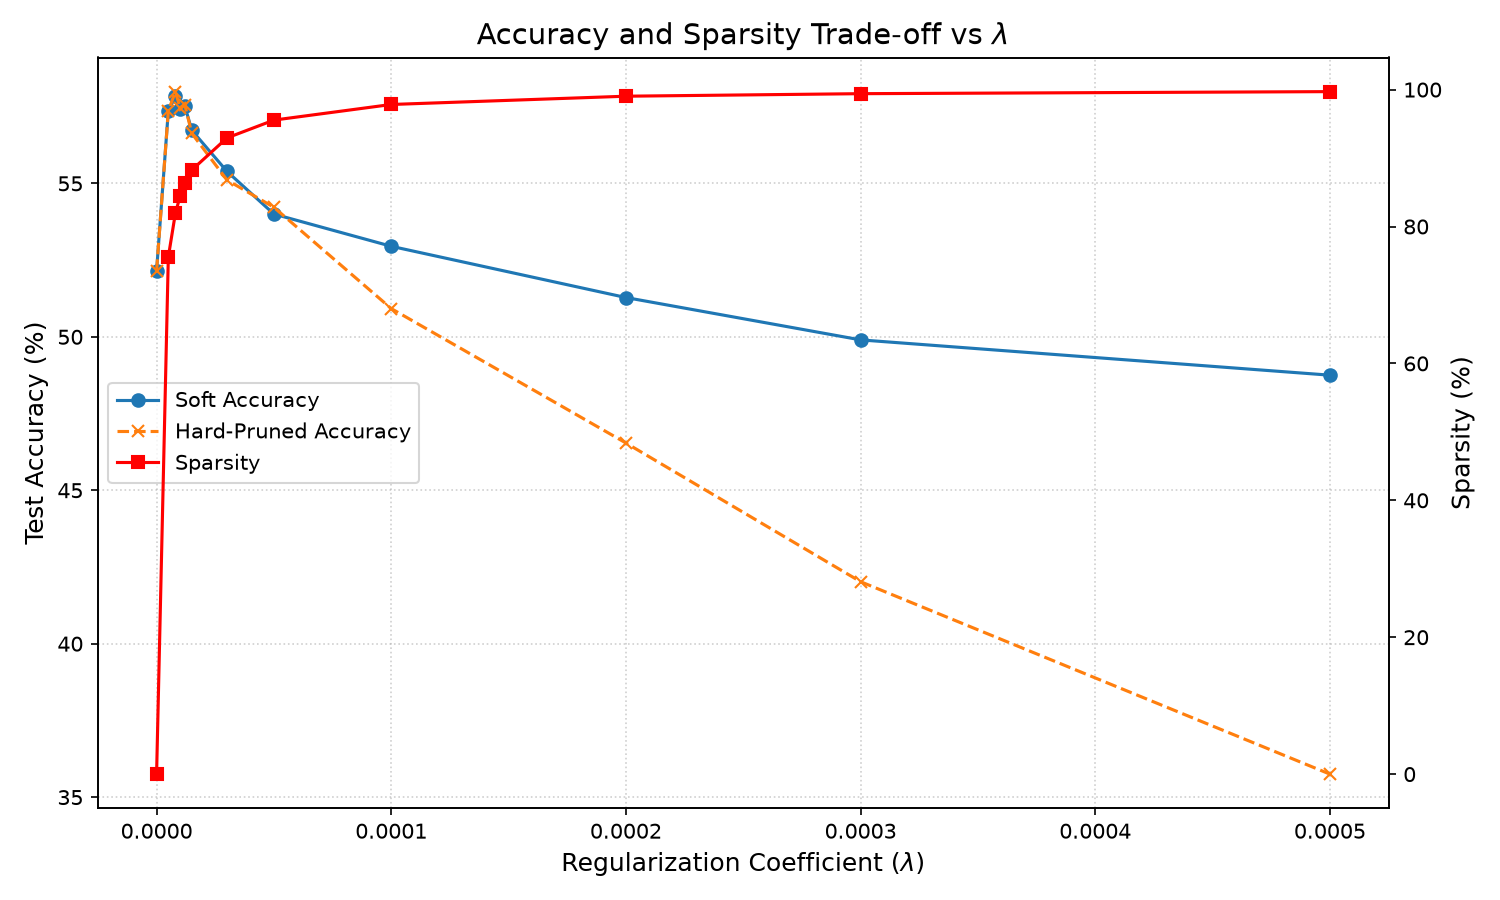

The plot shows that sparsity increases almost monotonically as $\lambda$ increases. However, accuracy reaches its highest value around $\lambda=8e-6$ and then decreases as increasingly aggressive pruning removes useful connections.

---

## 5. Final Gate Distribution

The following plot shows the distribution of gate values for the best model, obtained with $\lambda=8e-6$.

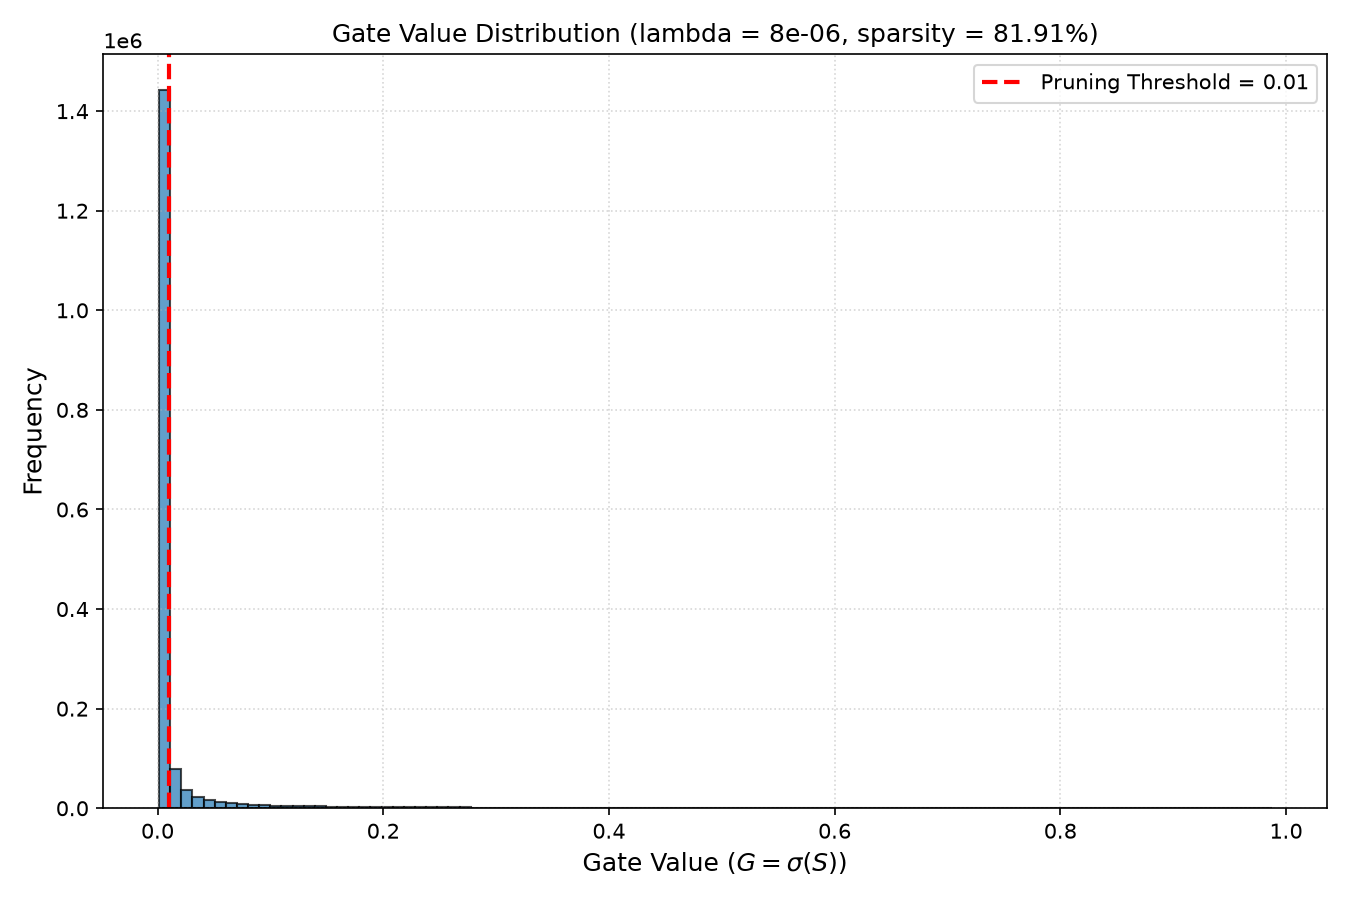

The distribution contains a very large concentration of gate values below the pruning threshold of `0.01`, demonstrating that the L1 gate regularization successfully drives a large fraction of the connections toward inactive states.

The remaining gates form a smaller distribution away from zero, representing connections that retain relatively larger gate values and remain active.

The best model has:

- **Lambda:** $8e-6$
- **Soft Test Accuracy:** 57.85%
- **Hard-Pruned Test Accuracy:** **57.99%**
- **Sparsity:** **81.91%**
- **Pruned Connections:** 1,423,663
- **Active Connections:** 314,321
- **Total Prunable Connections:** 1,737,984

---

## 6. Conclusion

The experiments demonstrate that the proposed self-pruning neural network can learn which connections are less important during training through learnable sigmoid gates and L1 sparsity regularization.

The best observed result was obtained with $\lambda=8e-6$, where the network achieved **57.99% hard-pruned test accuracy while pruning 81.91% of its prunable connections**.

Increasing $\lambda$ beyond this point produced progressively higher sparsity but reduced classification accuracy. Therefore, the experiments demonstrate the intended trade-off between model sparsity and classification performance.

Overall, the results show that the network is capable of learning a highly sparse connectivity pattern without requiring a separate post-training pruning procedure.

### GitHub Link (To Project) : 
### The complete source code and reports are available in our [GitHub Repository](https://github.com/ganapavijaykumarreddy1/SelfPruningNN.git).

### GitHub Profile (Vijay Kumar Reddy Ganapa): [GitHub Repository](https://github.com/ganapavijaykumarreddy1).